In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Define your save path
SAVE_DIR = '/content/drive/MyDrive/wgan-cifar/checkpoints'

Mounted at /content/drive


In [2]:
# All of these come pre-installed on Colab, just importing
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid
import numpy as np
import matplotlib.pyplot as plt
import os

# Confirm GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")  # Should print: Using device: cuda

Using device: cuda


In [3]:
# Data
IMAGE_SIZE = 32
CHANNELS = 3          # CIFAR is RGB
NUM_CLASSES = 10      # not used in unconditional GAN, just for reference

# Architecture
LATENT_DIM = 128      # size of the noise vector fed to Generator
FEATURES_GEN = 64     # base feature size for Generator
FEATURES_CRITIC = 64  # base feature size for Critic

# Training
BATCH_SIZE = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
CRITIC_ITERATIONS = 5  # train critic 5x per generator update (WGAN rule)
LAMBDA_GP = 10         # gradient penalty weight (WGAN-GP standard)

# Saving
SAVE_INTERVAL = 10    # save checkpoint every 10 epochs
SAMPLE_INTERVAL = 5   # save sample images every 5 epochs

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),   # normalize each RGB channel
        std=(0.5, 0.5, 0.5)     # output range becomes [-1, 1]
    )
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

print(f"Dataset size: {len(dataset)} images")
print(f"Batches per epoch: {len(dataloader)}")

100%|██████████| 170M/170M [00:03<00:00, 48.7MB/s]


Dataset size: 50000 images
Batches per epoch: 782


In [5]:
class Generator(nn.Module):
    def __init__(self, latent_dim, features, channels):
        super(Generator, self).__init__()

        self.net = nn.Sequential(
            # Input: latent_dim x 1 x 1
            self._block(latent_dim, features * 8, 4, 1, 0),  # 4x4
            self._block(features * 8, features * 4, 4, 2, 1), # 8x8
            self._block(features * 4, features * 2, 4, 2, 1), # 16x16
            # Final layer: no BatchNorm, Tanh activation
            nn.ConvTranspose2d(features * 2, channels, 4, 2, 1), # 32x32
            nn.Tanh()
        )

    def _block(self, in_ch, out_ch, kernel, stride, padding):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
class Critic(nn.Module):
    def __init__(self, channels, features):
        super(Critic, self).__init__()

        self.net = nn.Sequential(
            # Input: channels x 32 x 32
            # No BatchNorm in first layer (WGAN-GP requirement)
            nn.Conv2d(channels, features, 4, 2, 1),       # 16x16
            nn.LeakyReLU(0.2, inplace=True),
            self._block(features,     features * 2, 4, 2, 1),  # 8x8
            self._block(features * 2, features * 4, 4, 2, 1),  # 4x4
            nn.Conv2d(features * 4, 1, 4, 1, 0),               # 1x1
            # No Sigmoid — critic outputs raw scores, not probabilities
        )

    def _block(self, in_ch, out_ch, kernel, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.InstanceNorm2d(out_ch, affine=True),  # InstanceNorm for WGAN-GP
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
def gradient_penalty(critic, real, fake, device):
    batch_size, C, H, W = real.shape

    # Random interpolation between real and fake
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = alpha * real + (1 - alpha) * fake
    interpolated.requires_grad_(True)

    # Critic score on interpolated images
    critic_interpolated = critic(interpolated)

    # Compute gradients
    gradients = torch.autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True,
        retain_graph=True
    )[0]

    gradients = gradients.view(gradients.shape[0], -1)
    gp = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gp

In [8]:
gen = Generator(LATENT_DIM, FEATURES_GEN, CHANNELS).to(device)
critic = Critic(CHANNELS, FEATURES_CRITIC).to(device)

opt_gen = optim.Adam(gen.parameters(), lr=LEARNING_RATE, betas=(0.0, 0.9))
opt_critic = optim.Adam(critic.parameters(), lr=LEARNING_RATE, betas=(0.0, 0.9))

# Fixed noise to track visual progress across epochs
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)

# Loss tracking
gen_losses = []
critic_losses = []

print("Models initialised successfully")
print(f"Generator parameters: {sum(p.numel() for p in gen.parameters()):,}")
print(f"Critic parameters:    {sum(p.numel() for p in critic.parameters()):,}")

Models initialised successfully
Generator parameters: 3,677,955
Critic parameters:    663,361


In [9]:
os.makedirs(f'{SAVE_DIR}/samples', exist_ok=True)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_critic_loss = 0
    epoch_gen_loss = 0

    for batch_idx, (real, _) in enumerate(dataloader):
        real = real.to(device)
        batch_size = real.shape[0]

        # ─── Train Critic ───────────────────────────────────────
        for _ in range(CRITIC_ITERATIONS):
            noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake = gen(noise).detach()

            critic_real = critic(real).reshape(-1)
            critic_fake = critic(fake).reshape(-1)
            gp = gradient_penalty(critic, real, fake, device)

            loss_critic = -(torch.mean(critic_real) - torch.mean(critic_fake)) + LAMBDA_GP * gp

            opt_critic.zero_grad()
            loss_critic.backward()
            opt_critic.step()

        # ─── Train Generator ─────────────────────────────────────
        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake = gen(noise)
        critic_fake = critic(fake).reshape(-1)
        loss_gen = -torch.mean(critic_fake)

        opt_gen.zero_grad()
        loss_gen.backward()
        opt_gen.step()

        epoch_critic_loss += loss_critic.item()
        epoch_gen_loss += loss_gen.item()

    # ─── End of Epoch ────────────────────────────────────────────
    avg_c = epoch_critic_loss / len(dataloader)
    avg_g = epoch_gen_loss / len(dataloader)
    critic_losses.append(avg_c)
    gen_losses.append(avg_g)

    print(f"Epoch [{epoch}/{NUM_EPOCHS}] | Critic Loss: {avg_c:.4f} | Gen Loss: {avg_g:.4f}")

    # Save sample images
    if epoch % SAMPLE_INTERVAL == 0:
        gen.eval()
        with torch.no_grad():
            samples = gen(fixed_noise)
            save_image(samples, f'{SAVE_DIR}/samples/epoch_{epoch:03d}.png',
                      nrow=8, normalize=True)
        gen.train()

    # Save checkpoint
    if epoch % SAVE_INTERVAL == 0:
        torch.save(gen.state_dict(), f'{SAVE_DIR}/generator_epoch_{epoch}.pth')
        torch.save(critic.state_dict(), f'{SAVE_DIR}/critic_epoch_{epoch}.pth')
        print(f"  ✓ Checkpoint saved at epoch {epoch}")

print("Training complete!")

Epoch [1/100] | Critic Loss: -13.6514 | Gen Loss: 29.0656
Epoch [2/100] | Critic Loss: -7.4808 | Gen Loss: 35.7381
Epoch [3/100] | Critic Loss: -5.2821 | Gen Loss: 39.0657
Epoch [4/100] | Critic Loss: -4.9290 | Gen Loss: 43.5949
Epoch [5/100] | Critic Loss: -4.6338 | Gen Loss: 47.2382
Epoch [6/100] | Critic Loss: -4.4875 | Gen Loss: 48.6398
Epoch [7/100] | Critic Loss: -4.3479 | Gen Loss: 49.8572
Epoch [8/100] | Critic Loss: -4.1954 | Gen Loss: 50.5165
Epoch [9/100] | Critic Loss: -4.0399 | Gen Loss: 52.1461
Epoch [10/100] | Critic Loss: -3.8790 | Gen Loss: 53.9724
  ✓ Checkpoint saved at epoch 10
Epoch [11/100] | Critic Loss: -3.7363 | Gen Loss: 54.2915
Epoch [12/100] | Critic Loss: -3.6093 | Gen Loss: 54.6160
Epoch [13/100] | Critic Loss: -3.5647 | Gen Loss: 54.6090
Epoch [14/100] | Critic Loss: -3.4846 | Gen Loss: 55.4562
Epoch [15/100] | Critic Loss: -3.4451 | Gen Loss: 56.3773
Epoch [16/100] | Critic Loss: -3.3425 | Gen Loss: 57.0247
Epoch [17/100] | Critic Loss: -3.2512 | Gen Los

Final generator saved to Drive


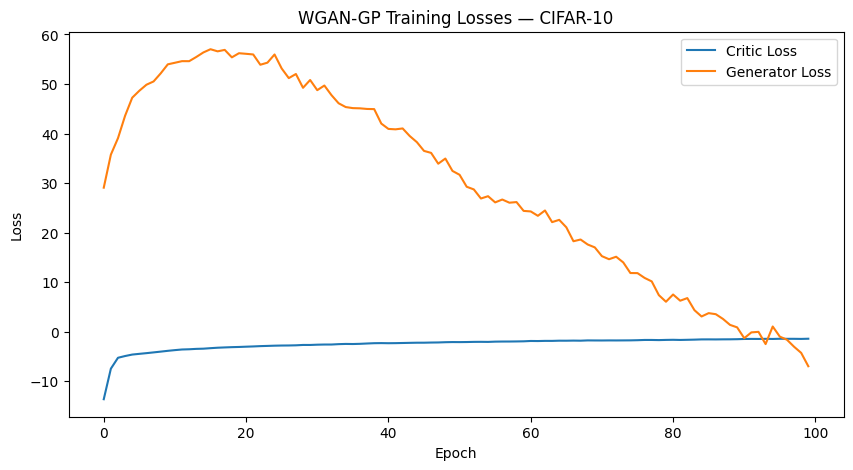

Loss curve saved


In [10]:
# Save final generator (this is what Flask will load)
torch.save(gen.state_dict(), f'{SAVE_DIR}/generator_final.pth')
print("Final generator saved to Drive")

# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(critic_losses, label='Critic Loss')
plt.plot(gen_losses, label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('WGAN-GP Training Losses — CIFAR-10')
plt.legend()
plt.savefig(f'{SAVE_DIR}/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curve saved")

In [11]:
from google.colab import files
files.download(f'{SAVE_DIR}/generator_final.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>